# Homework 4

This file contains code to solve problems on Homework 4 issued by Akil Narayan.

### Problem 2.20

Use the Yale Face Database dataset on Kaggle, or an equivalent labeled face dataset, for the following reproducible experiments. State the dataset, preprocessing, selected observations, values of 𝑘, and error measure.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

SEED = 0

In [31]:
rng = np.random.default_rng(SEED)

# Load data
faces = fetch_olivetti_faces(shuffle=True, random_state=SEED)

images = faces.images          # shape: (400, 64, 64)
labels = faces.target          # subject labels 0,...,39
n_images, h, w = images.shape

1. Treat each of several grayscale images separately as a matrix. Plot rank-𝑘 truncated-SVD approximations for several 𝑘 and report the reconstruction error. This is image compression by low-rank SVD, not PCA.

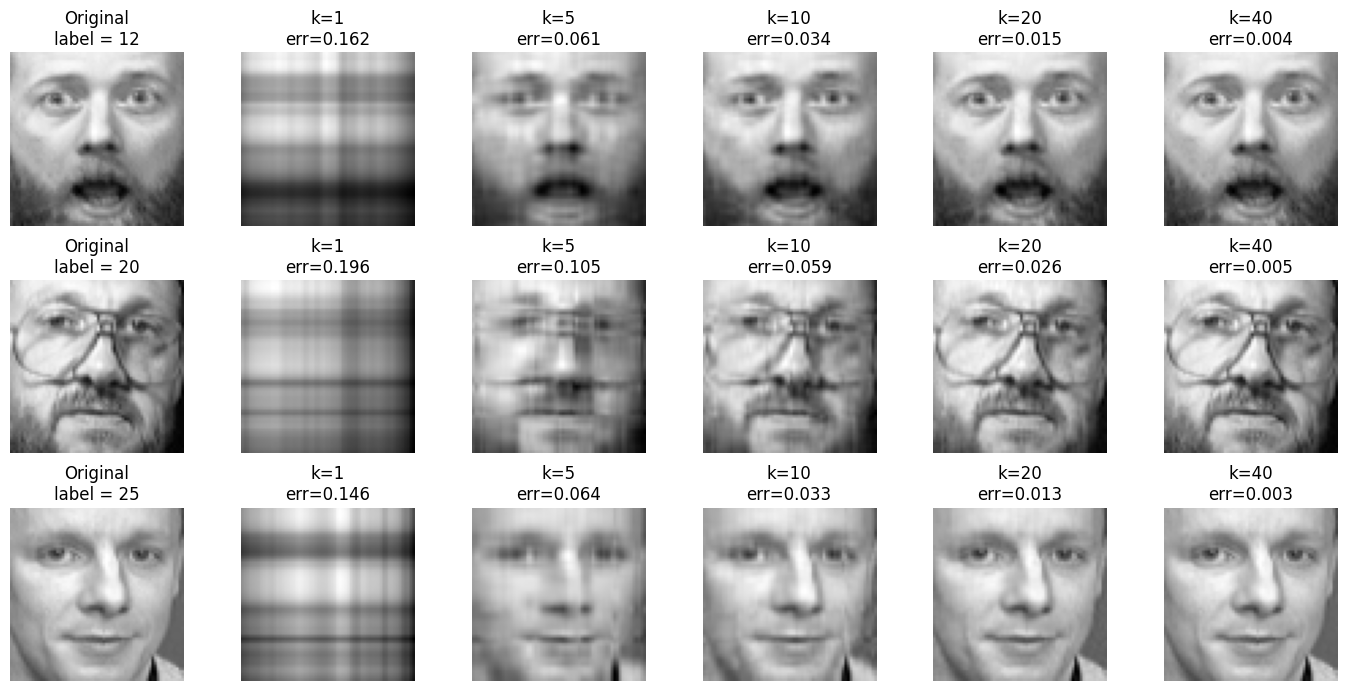

In [43]:
chosen_idx = [127, 200, 255]
k_svd = [1, 5, 10, 20, 40]

def truncated_svd(A, k):
    """Return rank-k SVD approximation of image matrix A."""
    U, s, VT = np.linalg.svd(A, full_matrices=False)
    return (U[:, :k] * s[:k]) @ VT[:k, :]

def relative_frobenius_error(A, A_k):
    return np.linalg.norm(A - A_k, "fro") / np.linalg.norm(A, "fro")

# Plot original images and their low-rank approximations
fig, axes = plt.subplots(len(chosen_idx), len(k_svd) + 1,
                         figsize=(14, 7))

for row, idx in enumerate(chosen_idx):
    A = images[idx]

    axes[row, 0].imshow(A, cmap="gray")
    axes[row, 0].set_title(f"Original\nlabel = {labels[idx]}")
    axes[row, 0].axis("off")

    for col, k in enumerate(k_svd, start=1):
        A_k = truncated_svd(A, k)
        err = relative_frobenius_error(A, A_k)

        axes[row, col].imshow(A_k, cmap="gray")
        axes[row, col].set_title(f"k={k}\nerr={err:.3f}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [33]:
for idx in chosen_idx:
    A = images[idx]
    print(f"\nImage {idx}, subject label {labels[idx]}")
    
    for k in k_svd:
        A_k = truncated_svd(A, k)
        err = relative_frobenius_error(A, A_k)
        print(f"k = {k:2d}, relative Frobenius error = {err:.6f}")


Image 254, subject label 32
k =  1, relative Frobenius error = 0.195661
k =  5, relative Frobenius error = 0.095537
k = 10, relative Frobenius error = 0.054700
k = 20, relative Frobenius error = 0.023177
k = 40, relative Frobenius error = 0.005616

Image 204, subject label 27
k =  1, relative Frobenius error = 0.216107
k =  5, relative Frobenius error = 0.109690
k = 10, relative Frobenius error = 0.068966
k = 20, relative Frobenius error = 0.034280
k = 40, relative Frobenius error = 0.008795

Image 338, subject label 35
k =  1, relative Frobenius error = 0.167774
k =  5, relative Frobenius error = 0.079920
k = 10, relative Frobenius error = 0.049290
k = 20, relative Frobenius error = 0.020983
k = 40, relative Frobenius error = 0.005283


Now we will fit PCA to these faces, using code provided by Braxton Osting in my MATH 5750: Math of Data Science class that I am also enrolled in this semester.

2. Vectorize a collection of images as columns of a data matrix, subtract the sample mean, and compute centered rank-𝑘 PCA reconstructions. Compare reconstruction accuracy across several 𝑘 with the single-image experiment.

In [52]:
from sklearn.decomposition import PCA

def relative_error(X, X_hat):
    """Reconstruction error as a fraction of the size of the data, ||X - X_hat||_F / ||X||_F."""
    return np.linalg.norm(X - X_hat) / np.linalg.norm(X)

faces = fetch_olivetti_faces(shuffle=True, random_state=SEED)
Y_faces = faces.data
labels = faces.target

height, width = faces.images.shape[1:]
mean_face = Y_faces.mean(axis=0)

# PCA automatically centers Y_faces before computing its components
pca_faces = PCA(random_state=SEED).fit(Y_faces)

ratios = pca_faces.explained_variance_ratio_
rank = int((ratios > 1e-10).sum())
cumulative = np.cumsum(ratios[:rank])

print(f"N = {Y_faces.shape[0]}, d = {Y_faces.shape[1]}, rank = {rank}")
print(f"first three components explain {cumulative[2]:.1%}")

for target in (0.90, 0.95, 0.99):
    print(f"{target:.0%} of the variance needs "
          f"p = {np.searchsorted(cumulative, target) + 1}")

RANKS = [1, 5, 10, 25, 50, 100, 399]

# Chosen observation: the 11th image in the data set
subject = Y_faces[10]
subject_label = labels[10]

reconstructions = {}

for p in RANKS:
    truncated = PCA(n_components=p, random_state=SEED).fit(Y_faces)

    reconstructions[p] = truncated.inverse_transform(
        truncated.transform(subject[None, :])
    )[0]

    print(f"p = {p:3d}, "
          f"relative centered reconstruction error = "
          f"{relative_error(subject - mean_face, reconstructions[p] - mean_face):.3f}")

N = 400, d = 4096, rank = 399
first three components explain 45.8%
90% of the variance needs p = 66
95% of the variance needs p = 123
99% of the variance needs p = 260
p =   1, relative centered reconstruction error = 0.997
p =   5, relative centered reconstruction error = 0.964
p =  10, relative centered reconstruction error = 0.892
p =  25, relative centered reconstruction error = 0.733
p =  50, relative centered reconstruction error = 0.510
p = 100, relative centered reconstruction error = 0.384
p = 399, relative centered reconstruction error = 0.000


In [49]:
# fig = plt.figure(figsize=(11, 4.6))
# grid = fig.add_gridspec(3, 8, height_ratios=[1, 1, 1.15],
#                         hspace=0.28, wspace=0.08)

# def show_image(ax, vector, title):
#     ax.imshow(vector.reshape(height, width), cmap="gray")
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_title(title, fontsize=7, pad=2)

# show_image(fig.add_subplot(grid[0, 0]), mean_face, r"mean $\mu$")
# for k in range(7):
#     show_image(fig.add_subplot(grid[0, k + 1]),
#                pca_faces.components_[k],
#                f"$u_{{{k + 1}}}$")

# show_image(fig.add_subplot(grid[1, 0]),
#            subject,
#            f"original\nlabel = {subject_label}")

# for k, p in enumerate(RANKS):
#     show_image(fig.add_subplot(grid[1, k + 1]),
#                reconstructions[p],
#                f"$p={p}$")

# ax = fig.add_subplot(grid[2, 0:3])
# ax.plot(np.arange(1, rank + 1), ratios[:rank], color="#cc0000", lw=1.2)
# ax.set_yscale("log")
# ax.set_xlabel("component $i$", fontsize=8)
# ax.set_ylabel("explained variance ratio", fontsize=7.5)
# ax.tick_params(labelsize=7)
# ax.grid(alpha=0.3)

# ax = fig.add_subplot(grid[2, 4:8])
# ax.plot(np.arange(1, rank + 1), cumulative, color="#4a4a4a", lw=1.2)

# for target in (0.90, 0.95, 0.99):
#     p = int(np.searchsorted(cumulative, target) + 1)
#     ax.plot([p, p], [0, target], color="#cc0000", lw=0.7, ls=":")
#     ax.annotate(f"{p}", (p, 0), color="#cc0000",
#                 xytext=(-4, -9), textcoords="offset points")

# ax.set_xlabel("number of components $p$", fontsize=8)
# ax.set_ylabel("cumulative explained variance", fontsize=7.5)
# ax.set_ylim(0, 1.02)
# ax.tick_params(labelsize=7)
# ax.grid(alpha=0.3)

# plt.show()

In [53]:
# Reuse the same three image indices from Part 1
chosen_idx = [127, 200, 255]
subjects = Y_faces[chosen_idx]
subject_labels = labels[chosen_idx]

reconstructions = {}

for p in RANKS:
    truncated = PCA(n_components=p, random_state=SEED).fit(Y_faces)

    # Reconstruct all three selected faces at once
    reconstructions[p] = truncated.inverse_transform(
        truncated.transform(subjects)
    )

    for i, subject in enumerate(subjects):
        err = relative_error(
            subject - mean_face,
            reconstructions[p][i] - mean_face
        )
        print(f"image {chosen_idx[i]}, p = {p:3d}, "
              f"relative error = {err:.3f}")

image 127, p =   1, relative error = 0.985
image 200, p =   1, relative error = 0.987
image 255, p =   1, relative error = 0.972
image 127, p =   5, relative error = 0.765
image 200, p =   5, relative error = 0.776
image 255, p =   5, relative error = 0.864
image 127, p =  10, relative error = 0.731
image 200, p =  10, relative error = 0.728
image 255, p =  10, relative error = 0.842
image 127, p =  25, relative error = 0.526
image 200, p =  25, relative error = 0.545
image 255, p =  25, relative error = 0.671
image 127, p =  50, relative error = 0.418
image 200, p =  50, relative error = 0.448
image 255, p =  50, relative error = 0.548
image 127, p = 100, relative error = 0.328
image 200, p = 100, relative error = 0.333
image 255, p = 100, relative error = 0.403
image 127, p = 399, relative error = 0.000
image 200, p = 399, relative error = 0.000
image 255, p = 399, relative error = 0.000


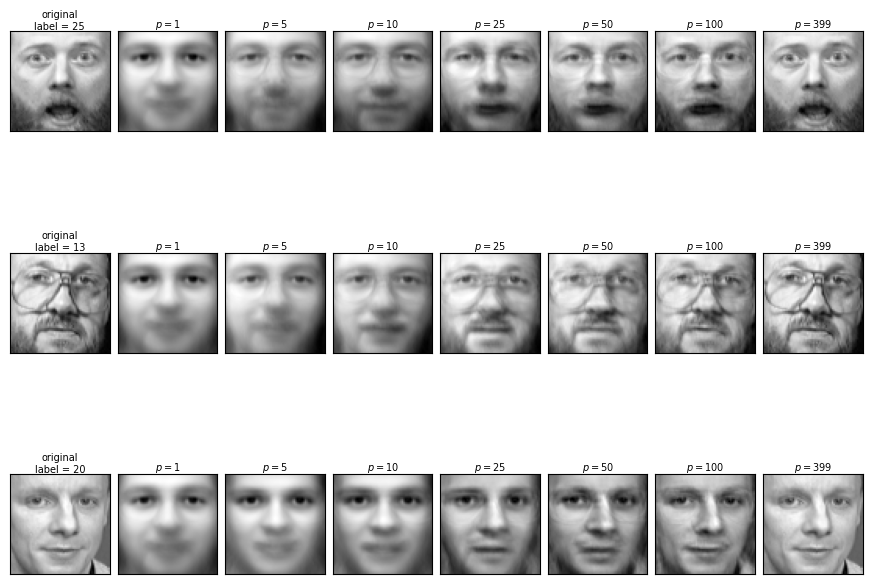

In [54]:
fig = plt.figure(figsize=(11, 8))
grid = fig.add_gridspec(3, 8, hspace=0.28, wspace=0.08)

def show_image(ax, vector, title):
    ax.imshow(vector.reshape(height, width), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=7, pad=2)

for row, subject in enumerate(subjects):
    show_image(fig.add_subplot(grid[row, 0]),
               subject,
               f"original\nlabel = {subject_labels[row]}")

    for col, p in enumerate(RANKS, start=1):
        show_image(fig.add_subplot(grid[row, col]),
                   reconstructions[p][row],
                   f"$p={p}$")

plt.show()

Now we will plot PCA scores

3. Plot the centered PCA scores in two and three dimensions. Describe any visible relationship between the embeddings and available face labels.

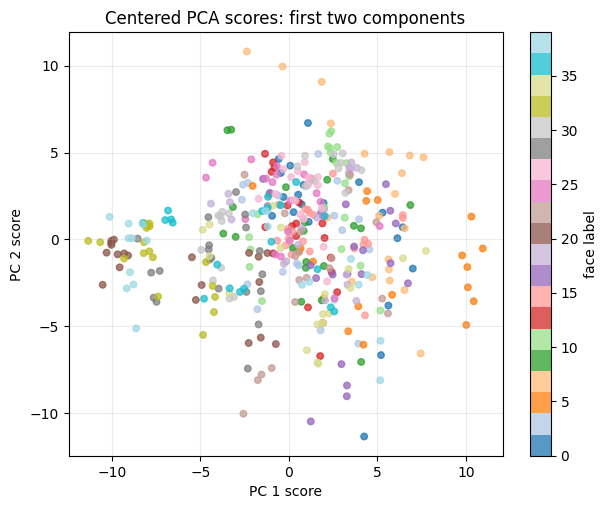

In [38]:
scores = pca_faces.transform(Y_faces)

# 2D PCA-score plot
fig, ax = plt.subplots(figsize=(7, 5.5))

scatter = ax.scatter(scores[:, 0], scores[:, 1],
                     c=labels, cmap="tab20",
                     s=22, alpha=0.75)

ax.set_xlabel("PC 1 score")
ax.set_ylabel("PC 2 score")
ax.set_title("Centered PCA scores: first two components")
ax.grid(alpha=0.25)

fig.colorbar(scatter, ax=ax, label="face label")
plt.show()

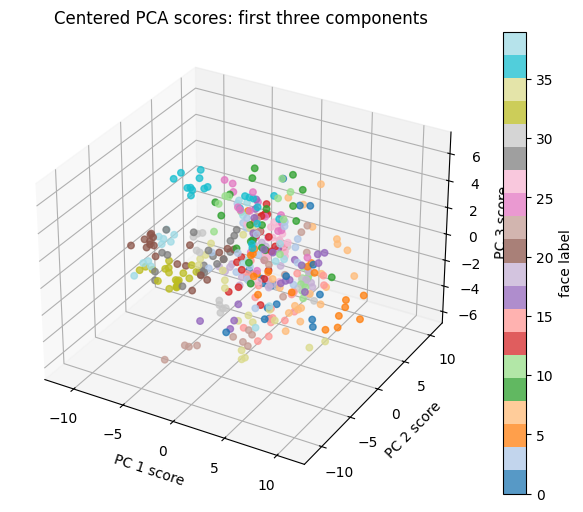

In [39]:
# 3D PCA-score plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(scores[:, 0], scores[:, 1], scores[:, 2],
                     c=labels, cmap="tab20",
                     s=22, alpha=0.75)

ax.set_xlabel("PC 1 score")
ax.set_ylabel("PC 2 score")
ax.set_zlabel("PC 3 score")
ax.set_title("Centered PCA scores: first three components")

fig.colorbar(scatter, ax=ax, label="face label")
plt.show()